In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

def load_benchmarks(files_dict):
    dfs = []
    for version_name, file_path in files_dict.items():
        df = pd.read_csv(file_path)
        df['version'] = version_name
        
        df['relative_range'] = df['fairness_max_min_ratio']
            
        dfs.append(df)
        
    return pd.concat(dfs, ignore_index=True)

experiments = {
    "Baseline": "benchmark_results_before_improvement.csv",
    "Interroute Moves": "benchmark_results_no_value_increase.csv",
    "Optimizing (Max-Min)/Min": "benchmark_results.csv",
}

df = load_benchmarks(experiments)
print(f"Loaded {len(df)} total problem instances across {len(experiments)} versions.")
df.head()

Loaded 20 total problem instances across 1 versions.


,problem_id,execution_time_sec,total_distance,total_time,fairness_gini,fairness_max_min_diff,fairness_max_min_ratio,agents_used,fairness_std_dev,AON,ST,max_iter,time_limit,version,relative_range
0,12,11.405706,9687,69687,0.178745,1280,2.479769,6,538.795802,5,0.025,300,15,Optimizing (Max-Min)/Min,2.479769
1,19,12.068139,10587,70587,0.174506,1669,3.959220,6,611.703836,5,0.025,300,15,Optimizing (Max-Min)/Min,3.959220
2,1,12.310833,10473,70473,0.134839,1151,2.175689,6,455.930824,5,0.025,300,15,Optimizing (Max-Min)/Min,2.175689
3,16,12.108399,8930,68930,0.271071,1907,5.767500,6,721.088914,5,0.025,300,15,Optimizing (Max-Min)/Min,5.767500
4,7,10.866415,10069,70069,0.207617,1672,3.872852,6,690.909646,5,0.025,300,15,Optimizing (Max-Min)/Min,3.872852


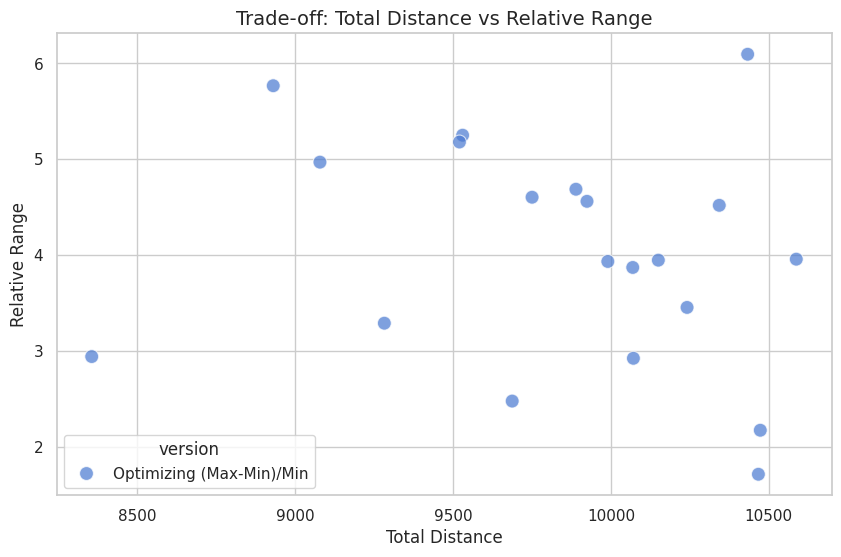

In [8]:
def scatterplot(df, x_metric='total_distance', y_metric='fairness_gini'):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df, 
        x=x_metric, 
        y=y_metric, 
        hue='version', 
        style='version',
        s=100, alpha=0.7
    )
    
    plt.title(f"Trade-off: {x_metric.replace('_', ' ').title()} vs {y_metric.replace('_', ' ').title()}", fontsize=14)
    plt.xlabel(x_metric.replace('_', ' ').title())
    plt.ylabel(y_metric.replace('_', ' ').title())
    plt.show()

scatterplot(df, x_metric='total_distance', y_metric='relative_range')

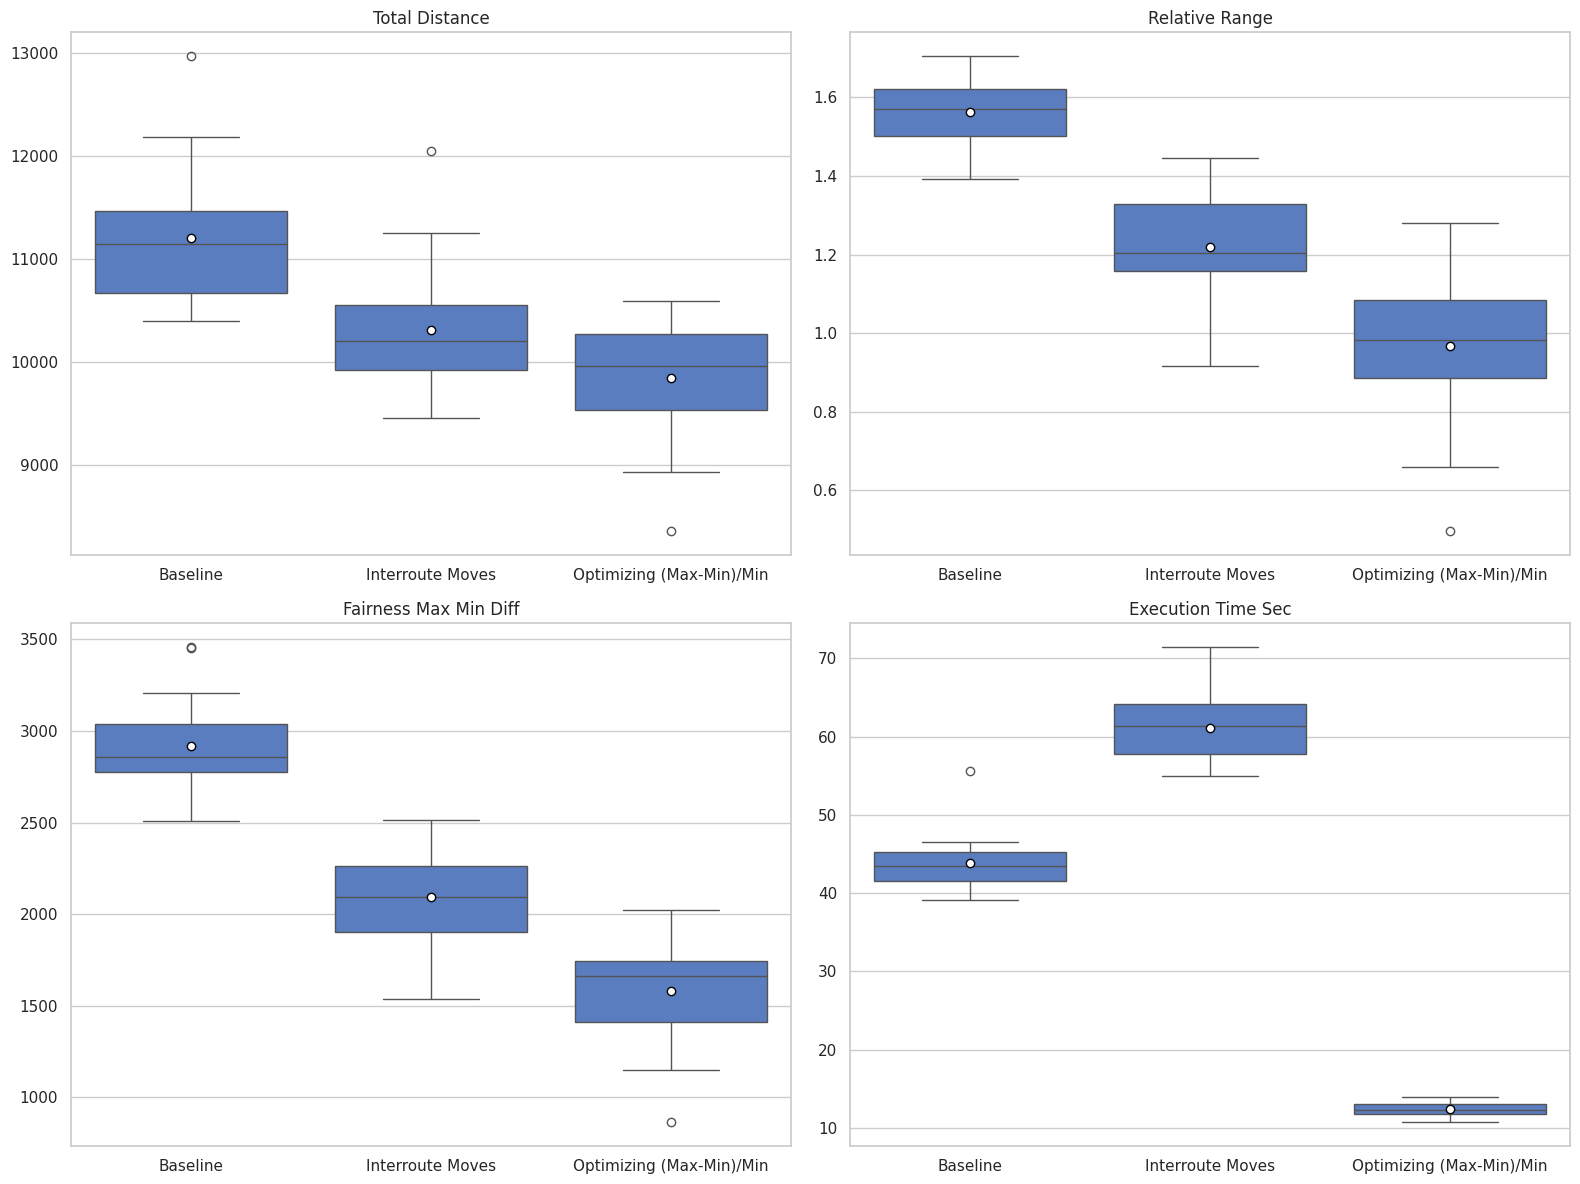

In [3]:
def compare_distributions(df, metrics: list[str]):
    rows, cols = 2, (len(metrics) + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))
    axes = axes.flatten()
    if len(metrics) == 1: axes = [axes]
        
    for i, metric in enumerate(metrics):
        sns.boxplot(
            data=df, x='version', y=metric, ax=axes[i],
            showmeans=True, meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
        )
        axes[i].set_title(metric.replace('_', ' ').title())
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")
        
    plt.tight_layout()
    plt.show()

compare_distributions(df, ['total_distance', 'relative_range', 'fairness_max_min_diff', 'execution_time_sec'])

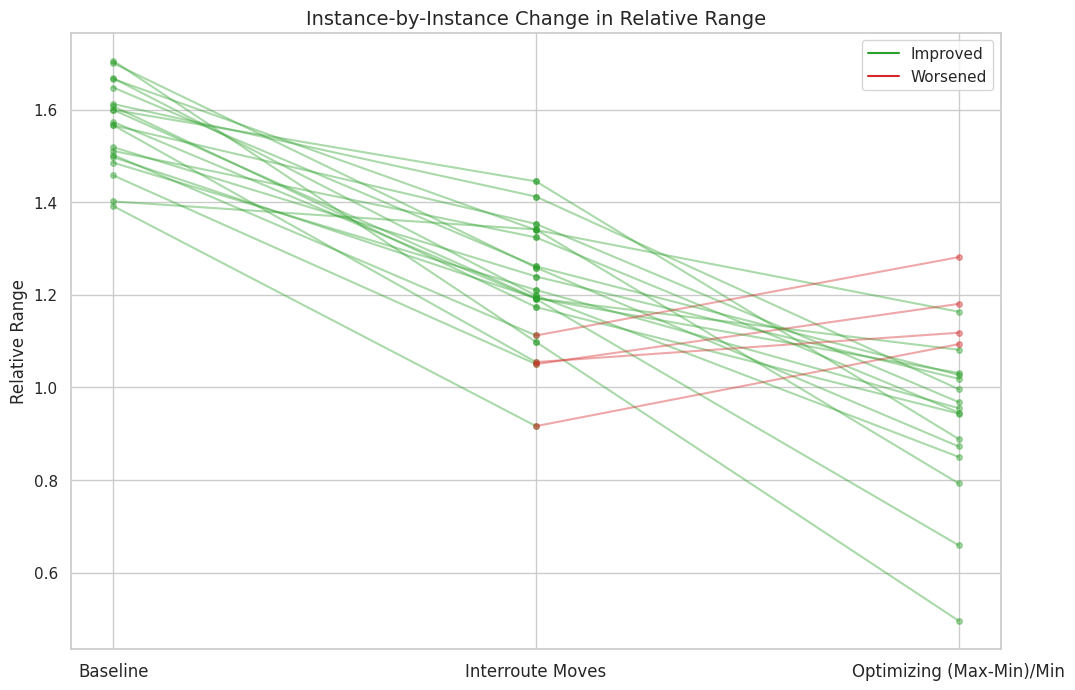

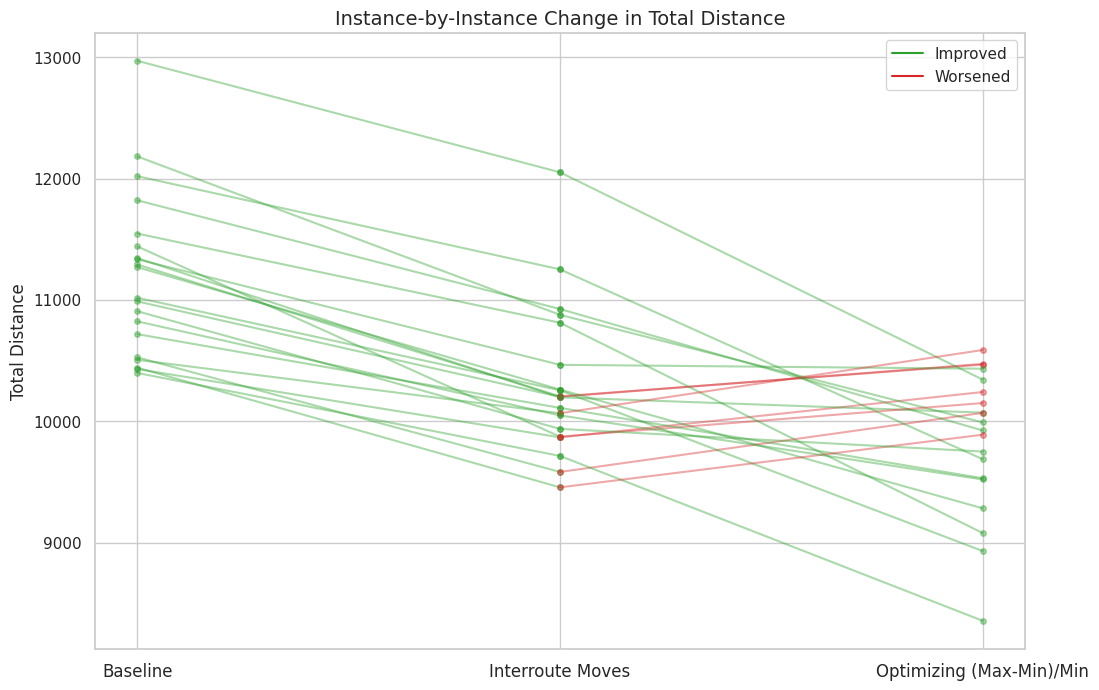

In [4]:
def plot_instance_slopes(df, metric):
    pivot_df = df.pivot(index='problem_id', columns='version', values=metric)
    versions = list(pivot_df.columns)
    
    plt.figure(figsize=(12, 8))

    for i in range(len(versions) - 1):
        
        v1, v2 = versions[i], versions[i + 1]
        
        
        for index, row in pivot_df.iterrows():
            y1, y2 = row[v1], row[v2]
            if pd.isna(y1) or pd.isna(y2): continue
                
            color = '#2ca02c' if y2 < y1 else '#d62728'
                
            plt.plot([i + 1, i + 2], [y1, y2], marker='o', markersize=4, color=color, alpha=0.4, linewidth=1.5)
            
    
    plt.xticks(range(1, len(versions) + 1), versions, fontsize=12)
    plt.ylabel(metric.replace('_', ' ').title())
    plt.title(f"Instance-by-Instance Change in {metric.replace('_', ' ').title()}", fontsize=14)
    
    import matplotlib.lines as mlines
    plt.legend(handles=[
        mlines.Line2D([], [], color='#2ca02c', label='Improved'),
        mlines.Line2D([], [], color='#d62728', label='Worsened')
    ])
    
    plt.show()

plot_instance_slopes(df, metric='relative_range')
plot_instance_slopes(df, metric='total_distance')